    Instructions:
    1. Run task_0a.py to generate the vector database if not already generated.
    2. Press Run All (or restart kernel and run all cells).
    3. You will be prompted to provide input values.


    Task 11: Implement a program which (a) given a feature model or latent space, (b) a value n, (c) a value m, and (d) a label l
        –   creates a similarity graph, G(V, E), where V corresponds to the images in the database and E contains node pairs Vi , Vj 
            such that, for each subject Vi, Vj is one of the n most similar images in the database in the given space

        –   identifies the most significant m images (relative to the given label l) using personalized PageRank measure. 
            See Huang, S., Li, X., Candan, K. S., Sapino, M. L. (2016). Reducing seed noise in personalized PageRank.
            Social Network Analysis and Mining, 6(1), 1-25.


In [41]:
FEATURE_SPACE_INPUT = input(
"""
Provide a feature model or latent space that was generated using tasks 3 to 6.

Feature space: [color, hog, avgpool, layer3, fc]

For latent semantics:
if you generated a latent semantic in task 3 from color space and svd,
enter "LS1_color_5_svd".
If you are unsure what to type here, please see Code/database/<name>_reducer.pt
after running the relevant task. Any <name> can be input here.
"""
)

N = int(input(
"""
Enter n - the count of most similar images in the database in the given space
"""
))

M = int(input(
"""
Enter m - the count of most significant images in the label to be returned as output of Personalized PageRank Algorithm
"""
))

L = input(
"""
Provide l - the label for which you want to find similar labels
"""
)
from utils.query_input_processor import check_label_is_valid

L = check_label_is_valid(L)

Input label:  airplanes
Files already downloaded and verified
Output label: airplanes 




In [42]:
# Get feature space
# todo: print reducer and feature space used
# todo: implement for latent space, what distance function to use for latent spaces, same as the feature space??

from utils.database_utils import retrieve
from utils.vector_utils import get_latent_feature_vectors

if FEATURE_SPACE_INPUT in ['color', 'hog', 'avgpool', 'layer3', 'fc', 'resnet']:
    FEATURE_SPACE_NAME = FEATURE_SPACE_INPUT
    feature_space = retrieve(f'{FEATURE_SPACE_INPUT}.pt')
    print(f"Feature Space: {FEATURE_SPACE_INPUT}")
else:
    print(FEATURE_SPACE_INPUT)
    LATENT_SPACE = FEATURE_SPACE_INPUT.split('_')[0]
    print(LATENT_SPACE)
    
    FEATURE_SPACE_NAME = FEATURE_SPACE_INPUT.split('_')[1]
    print(FEATURE_SPACE_NAME)

    # Load created latent space
    reducer = retrieve(f'{FEATURE_SPACE_INPUT}_reducer.pt')

    feature_vectors = retrieve(f'{FEATURE_SPACE_NAME}.pt')
    feature_space = get_latent_feature_vectors(feature_vectors, reducer)


Feature Space: avgpool


In [43]:
# Create a map from labels to image_ids

label2imageids = {}
for image_id, (label, _) in feature_space.items():
    if label not in label2imageids:
        label2imageids[label] = []

    label2imageids[label].append(image_id)

In [44]:
from utils.database_utils import exists, compressed_retrieve, compressed_store
from utils.distance_utils import get_distance_fn, distance_matrix
import numpy as np

# First we retrieve the distance matrix for the feature space if it exits, otherwise we compute it.
# The distance matrix DM for N elements is an NxN matrix where DMij is the distance between elements
# i and j. Since the distance matrix computation takes 3-10 mins, we pre-compute and cache it.

if exists(f'distance_matrix_{FEATURE_SPACE_INPUT}.pt'):
    dm = compressed_retrieve(f'distance_matrix_{FEATURE_SPACE_INPUT}.pt')
else:
    dm = distance_matrix(feature_space, get_distance_fn(FEATURE_SPACE_NAME))
    compressed_store(dm, f'distance_matrix_{FEATURE_SPACE_INPUT}.pt')

# Generate a similarity graph between images. It will be represented as an adjacency matrix
# with Vij = 1 if j is one of the n most similar images to i in the given feature space

similarity_graph = np.zeros((len(dm), len(dm)), dtype=float)
for i, row in enumerate(dm):
    similarity_graph[i][np.argsort(row)[:N]] = 1
similarity_graph

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [45]:
# Compute Personalized PageRank for the similarity graph

# Compute the transition matrix by dividing it with N (the number of outgoing edges per node) and transposing it
transition_matrix = (similarity_graph / N).T

# Set the damping factor for the PageRank algorithm
damping_factor = 0.85

# Initialize the PageRank vector with equal probabilities for all nodes
pr = np.full(len(similarity_graph), 1/len(similarity_graph), dtype=float)

# Get the indexes for the provided label by dividing the image ids by 2
label_indexes = np.array(label2imageids[L]) // 2
# Create a vector 's' with zeros, representing personalized probabilities.
s = np.zeros(len(similarity_graph), dtype=float)
# Assign a personalized probability to nodes associated with the label.
s[label_indexes] = 1 / len(label_indexes)

# Set the number of iterations for the PageRank algorithm.
iterations = 50


# Perform PageRank iterations to update node probabilities
for i in range(iterations):
    # Update PageRank values using the PageRank formula with the transition matrix and 's'.
    pr = ((damping_factor * transition_matrix) @ pr) + ((1 - damping_factor) * s)

Files already downloaded and verified



Query Label: airplanes


1 .	Image ID:  2608 		Label:  airplanes 		PageRank:  0.03419935309560859


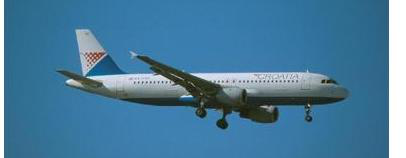

2 .	Image ID:  2562 		Label:  airplanes 		PageRank:  0.033542073633872446


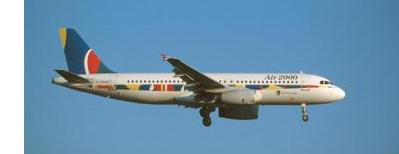

3 .	Image ID:  2256 		Label:  airplanes 		PageRank:  0.024222445721543903


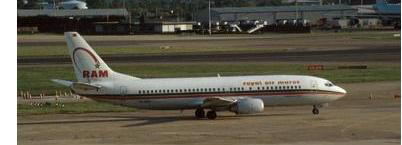

4 .	Image ID:  2636 		Label:  airplanes 		PageRank:  0.024196312467084594


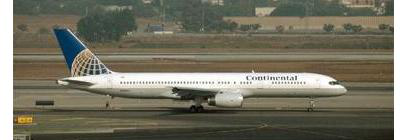

5 .	Image ID:  2604 		Label:  airplanes 		PageRank:  0.023343486410721728


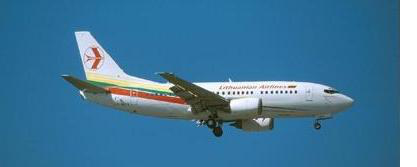

6 .	Image ID:  2626 		Label:  airplanes 		PageRank:  0.02312108985643363


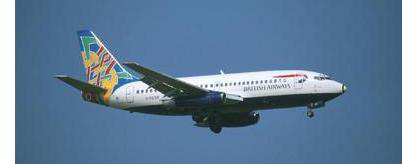

7 .	Image ID:  2260 		Label:  airplanes 		PageRank:  0.0195828601038256


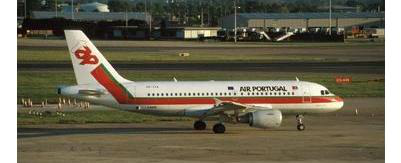

8 .	Image ID:  2566 		Label:  airplanes 		PageRank:  0.01888376266876689


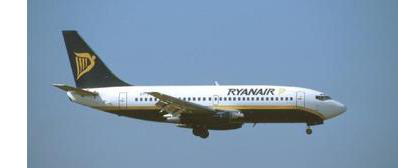

9 .	Image ID:  2420 		Label:  airplanes 		PageRank:  0.017171471468032985


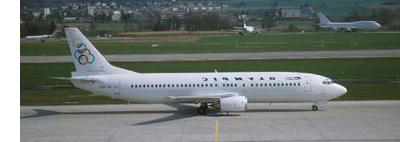

10 .	Image ID:  2418 		Label:  airplanes 		PageRank:  0.016266592760784647


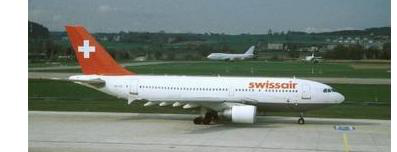

In [46]:
# Get top M significant images related to the provided label

top_m = []

# Get the indexes with the highest PageRank scores in the pr vector
for idx in np.argsort(pr)[:-M-1:-1]:
    imgid = idx * 2
    label = feature_space[imgid][0]
    pr_score = pr[idx]

    # Collect image_id, label and pagerank score to display
    top_m.append((imgid, label, pr_score))

from utils.dataset_utils import initialize_dataset
dataset = initialize_dataset()

print(f"\n\n\nQuery Label: {L}\n\n")

for i, (image_id, label, pagerank_score) in enumerate(top_m):
    print(i+1, ".\tImage ID: ", image_id, "\t\tLabel: ", label, "\t\tPageRank: ", pagerank_score)
    display(dataset[image_id][0])